# Đánh giá Mô hình Fine-Tuned (Mới)
Notebook này dùng để đánh giá mô hình vừa được train xong trên tập Test.
Sử dụng `DataLoader` và `batch_size` để quá trình infer diễn ra cực nhanh.

In [36]:
import os
import sys
import torch
from pathlib import Path
from torch.utils.data import DataLoader
from torchvision import transforms
from tqdm.notebook import tqdm
from sklearn.metrics import classification_report

# Thêm gốc của project vào sys.path
current_dir = Path.cwd()
PROJECT_ROOT = current_dir
while not (PROJECT_ROOT / 'src').exists() and PROJECT_ROOT.parent != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.append(str(PROJECT_ROOT))
print(f"Project Root: {PROJECT_ROOT}")

from src.datasets.multimodal_raw_dataset import MultiModalRawDataset, multimodal_raw_collate_fn
from src.evaluation.validation_metrics import bootstrap_classification_metrics

Project Root: /media/data3/users/luongdth/MulCo-PlantNet


## 1. Chuẩn bị Dataset & DataLoader

In [37]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_dir = PROJECT_ROOT / "data/processed/PlantDocSplited_depth_AUG/test"
caption_dir = PROJECT_ROOT / "data/AIDG/captions_LLaVA"
mapping_path = PROJECT_ROOT / "data/processed/PlantDocSplited_depth_AUG/global_image_caption_mapping.json"

test_dataset = MultiModalRawDataset(
    image_root=test_dir,
    caption_root=caption_dir,
    transform=test_transform,
    use_depth_suppressed=False,
    strict_caption_match=False,
    image_caption_mapping_path=str(mapping_path)
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32, 
    shuffle=False,
    num_workers=4,
    collate_fn=multimodal_raw_collate_fn
)

idx_to_class = test_dataset.idx_to_class
print(f"Total items to test: {len(test_dataset)}")

Using device: cuda
[MultiModalRawDataset] Loaded image-caption mapping: 5256 entries
[MultiModalRawDataset] Total selected images: 250
[MultiModalRawDataset] Valid samples: 250
[MultiModalRawDataset] Skipped missing caption: 0
[MultiModalRawDataset] Skipped invalid caption: 0
[MultiModalRawDataset] Matched by external mapping: 250
[MultiModalRawDataset] Num classes: 28
[MultiModalRawDataset] class_to_idx: {'Apple_Scab_Leaf': 0, 'Apple_leaf': 1, 'Apple_rust_leaf': 2, 'Bell_pepper_leaf': 3, 'Bell_pepper_leaf_spot': 4, 'Blueberry_leaf': 5, 'Cherry_leaf': 6, 'Corn_Gray_leaf_spot': 7, 'Corn_leaf_blight': 8, 'Corn_rust_leaf': 9, 'Peach_leaf': 10, 'Potato_leaf_early_blight': 11, 'Potato_leaf_late_blight': 12, 'Raspberry_leaf': 13, 'Soyabean_leaf': 14, 'Squash_Powdery_mildew_leaf': 15, 'Strawberry_leaf': 16, 'Tomato_Early_blight_leaf': 17, 'Tomato_Septoria_leaf_spot': 18, 'Tomato_leaf': 19, 'Tomato_leaf_bacterial_spot': 20, 'Tomato_leaf_late_blight': 21, 'Tomato_leaf_mosaic_virus': 22, 'Tomato

## 2. Load Model
**Lưu ý:** Hãy trỏ thư viện import tới đúng class model mà bạn vừa train.

In [38]:
# =====================================================================
# TODO: Cập nhật chính xác class mô hình MỚI (1 block, GAP) của bạn
# Ví dụ ở đây tôi đang import class MulCoEndToEnd (bạn hãy sửa nếu tên khác)
# =====================================================================
from src.models.multimodal.mulco_end_to_end import MulCoEndToEnd  # <--- BẠN HÃY SỬA DÒNG NÀY NẾU KHÁC
from transformers import AutoTokenizer

print("Loading Fine-Tuned Model...")
# Bạn có thể thêm tham số vào hàm khởi tạo nếu cần thiết
model = MulCoEndToEnd(num_classes=28).to(device) 

ckpt_path = PROJECT_ROOT / "archive/mulco_depth_aug_cb_focal/best_fine_tuned_model.pth"
model.load_state_dict(torch.load(ckpt_path, map_location=device, weights_only=True), strict=False)
model.eval()

print("Loading Tokenizer...")
# Nếu bạn dùng bert-base-uncased thì đổi tên model ở dưới nhé
text_tokenizer = AutoTokenizer.from_pretrained("roberta-base")
print("Model Loaded Successfully!")

Loading Fine-Tuned Model...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-base
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.bias        | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading Tokenizer...
Model Loaded Successfully!


## 3. Chạy Đánh Giá (Inference Loop)

In [39]:
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Testing Model"):
        images = batch["image"].to(device)
        texts = batch["text"] # List of strings
        labels = batch["label"].to(device)

        text_tokens = text_tokenizer(
            texts, 
            padding=True, 
            truncation=True, 
            max_length=256, 
            return_tensors="pt"
        )
        input_ids = text_tokens.input_ids.to(device)
        attention_mask = text_tokens.attention_mask.to(device)

        # Nếu class model của bạn yêu cầu tham số khác (VD model(images, texts, return_all...))
        # hãy chỉnh sửa lại dòng gọi forward này:
        logits = model(images, input_ids, attention_mask)
        
        # Xử lý nếu mô hình trả về Dictionary (như trong pvd_contrastive.py)
        if isinstance(logits, dict):
            logits = logits.get("logits", logits)
            
        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(labels.cpu().tolist())

Testing Model:   0%|          | 0/8 [00:00<?, ?it/s]

## 4. Báo cáo Kết quả (Metrics)

In [40]:
print("\n" + "="*55)
print(" ĐÁNH GIÁ MÔ HÌNH TRÊN TẬP TEST")
print("="*55)

metrics = bootstrap_classification_metrics(all_labels, all_preds)
point, ci = metrics["point"], metrics["ci"]

print(f"Accuracy:          {point['accuracy']:.4f} (95% CI: {ci['accuracy']['low']:.4f} - {ci['accuracy']['high']:.4f})")
print(f"Macro F1-Score:    {point['macro_f1']:.4f} (95% CI: {ci['macro_f1']['low']:.4f} - {ci['macro_f1']['high']:.4f})")
print(f"Balanced Accuracy: {point['balanced_accuracy']:.4f} (95% CI: {ci['balanced_accuracy']['low']:.4f} - {ci['balanced_accuracy']['high']:.4f})")

print("\n" + "-"*55)
print(" CLASSIFICATION REPORT CHI TIẾT TỪNG LỚP BỆNH")
class_names = [idx_to_class[i] for i in range(len(idx_to_class))]
print(classification_report(all_labels, all_preds, target_names=class_names, digits=4, zero_division=0))


 ĐÁNH GIÁ MÔ HÌNH TRÊN TẬP TEST


/media/data3/users/luongdth/anaconda3/envs/gr1/lib/python3.12/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/media/data3/users/luongdth/anaconda3/envs/gr1/lib/python3.12/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/media/data3/users/luongdth/anaconda3/envs/gr1/lib/python3.12/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/media/data3/users/luongdth/anaconda3/envs/gr1/lib/python3.12/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/media/data3/users/luongdth/anaconda3/envs/gr1/lib/python3.12/site-packages/sklearn/metrics/_classif

Accuracy:          0.8160 (95% CI: 0.7680 - 0.8680)
Macro F1-Score:    0.8091 (95% CI: 0.7537 - 0.8441)
Balanced Accuracy: 0.8238 (95% CI: 0.7760 - 0.8674)

-------------------------------------------------------
 CLASSIFICATION REPORT CHI TIẾT TỪNG LỚP BỆNH
                                      precision    recall  f1-score   support

                     Apple_Scab_Leaf     0.9000    1.0000    0.9474         9
                          Apple_leaf     0.8182    0.9000    0.8571        10
                     Apple_rust_leaf     1.0000    0.7000    0.8235        10
                    Bell_pepper_leaf     0.7778    0.8750    0.8235         8
               Bell_pepper_leaf_spot     0.7500    1.0000    0.8571         9
                      Blueberry_leaf     1.0000    0.9091    0.9524        11
                         Cherry_leaf     1.0000    1.0000    1.0000        10
                 Corn_Gray_leaf_spot     0.2727    0.7500    0.4000         4
                    Corn_leaf_blight  

/media/data3/users/luongdth/anaconda3/envs/gr1/lib/python3.12/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/media/data3/users/luongdth/anaconda3/envs/gr1/lib/python3.12/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/media/data3/users/luongdth/anaconda3/envs/gr1/lib/python3.12/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/media/data3/users/luongdth/anaconda3/envs/gr1/lib/python3.12/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/media/data3/users/luongdth/anaconda3/envs/gr1/lib/python3.12/site-packages/sklearn/metrics/_classif

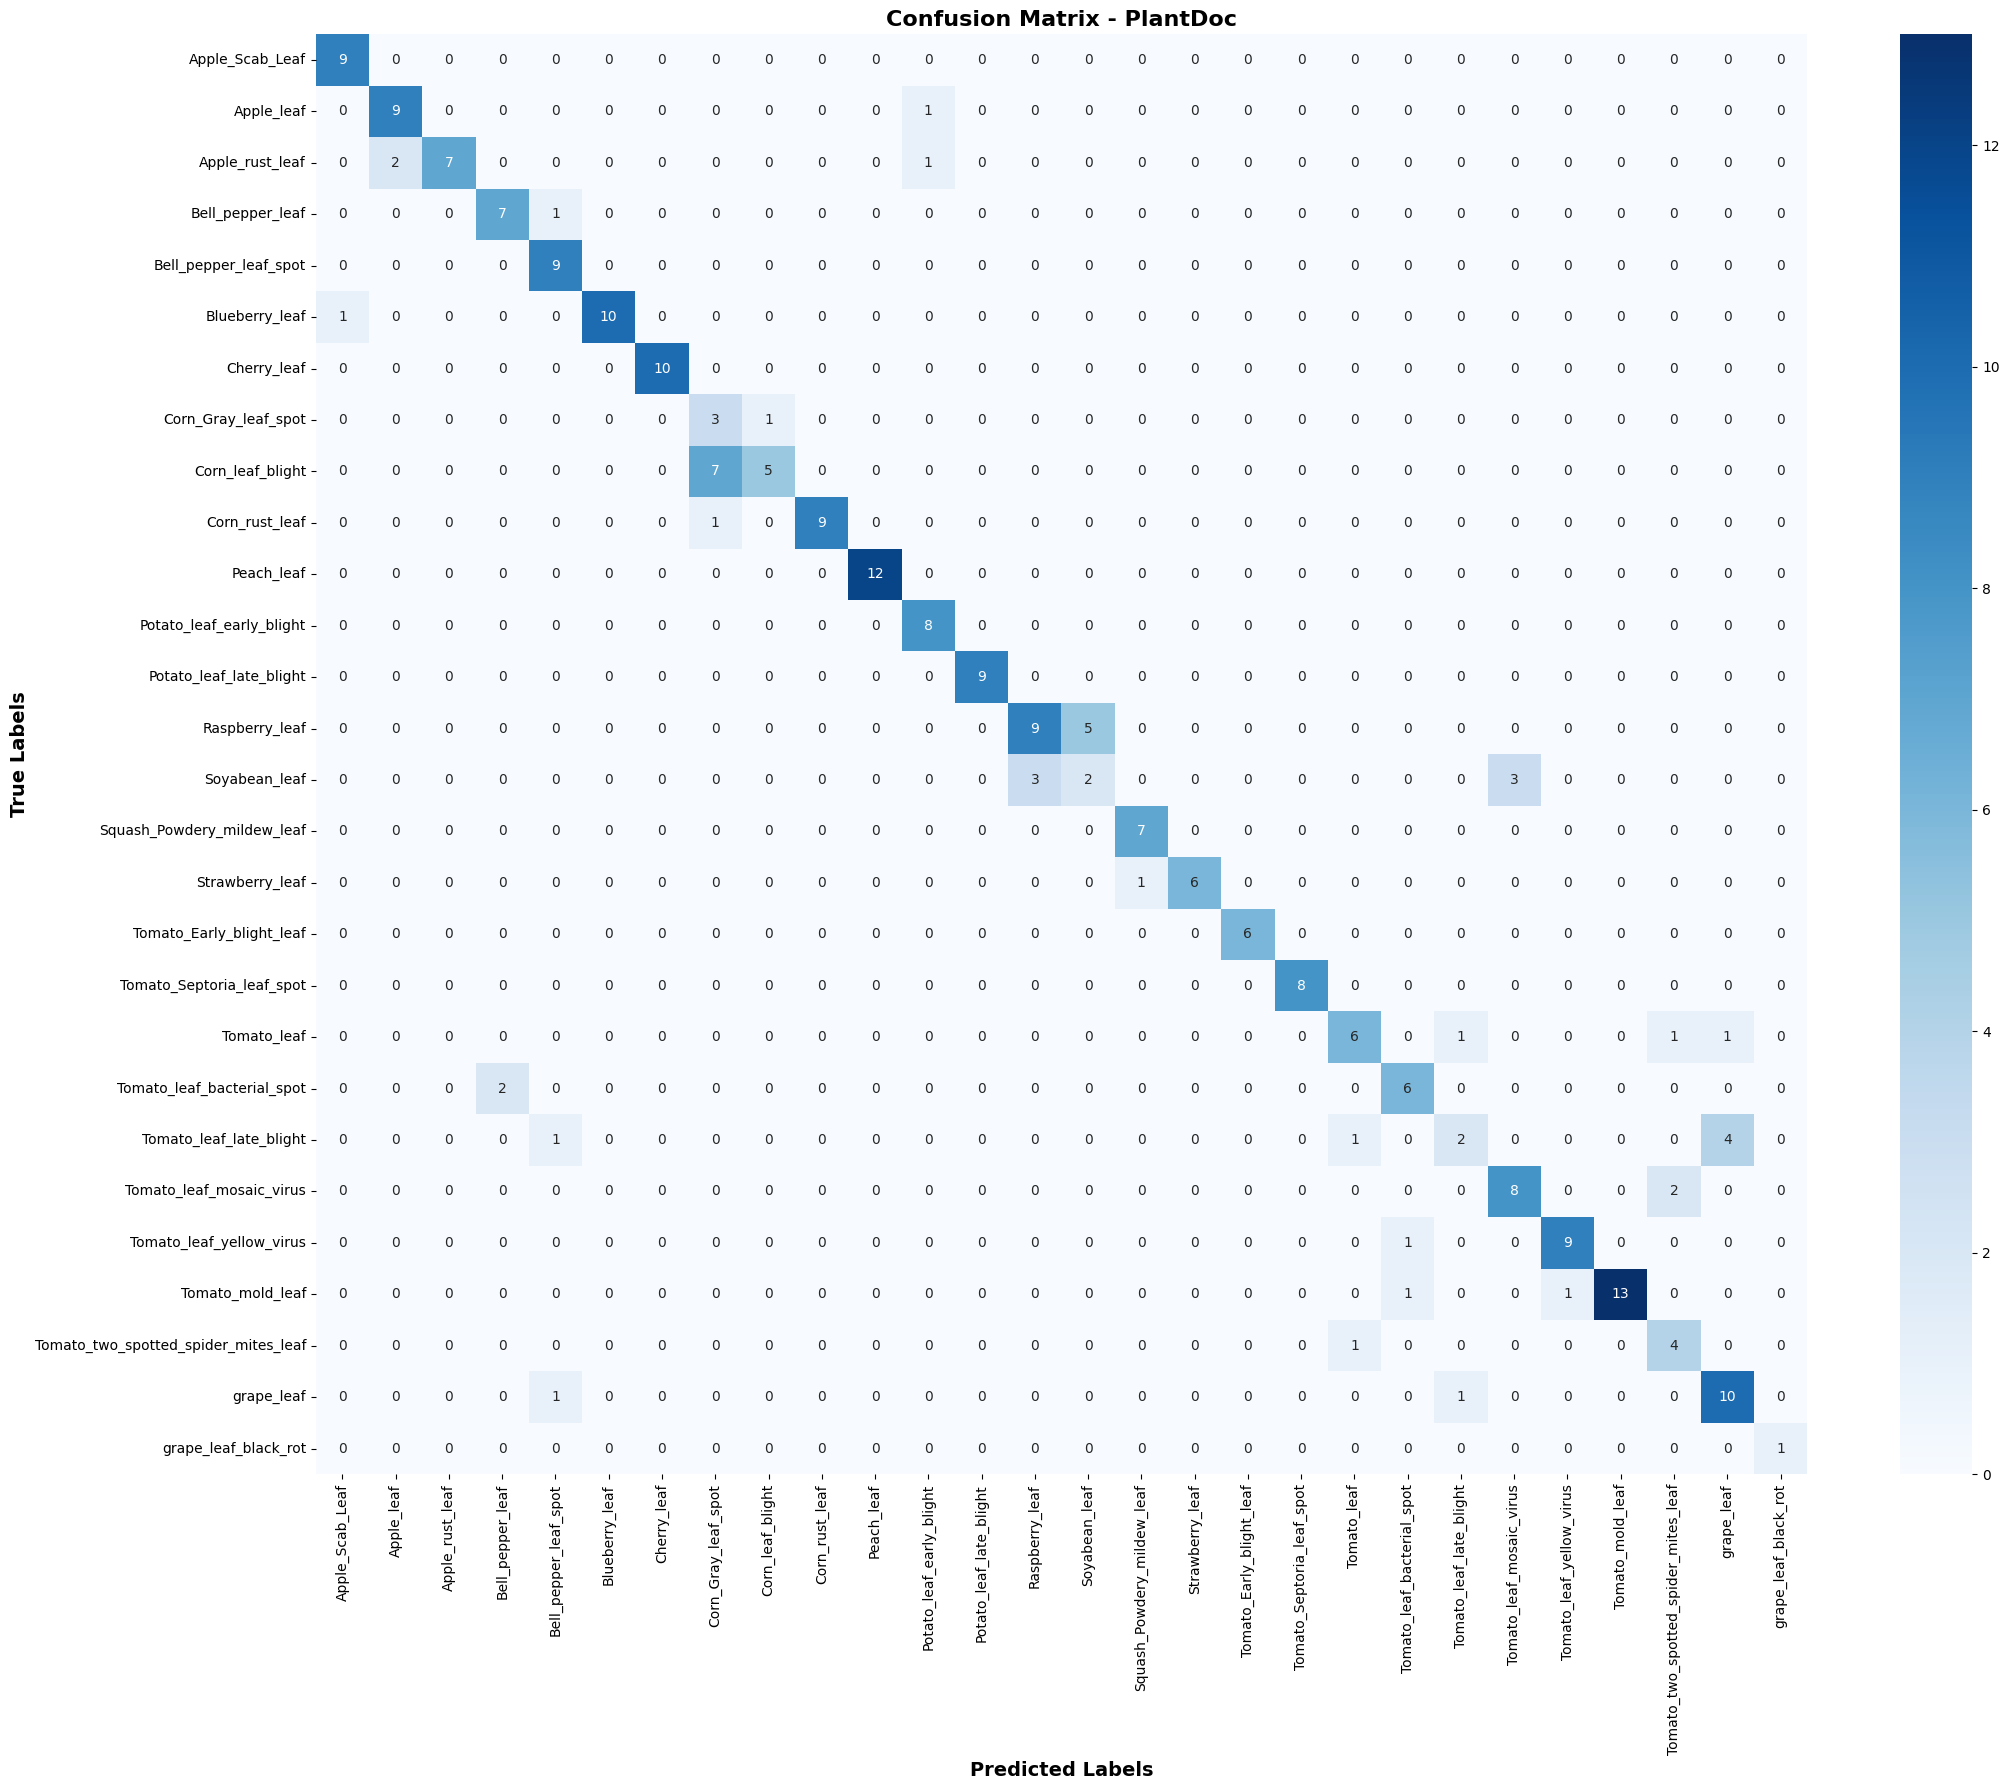

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Tạo Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

# Vẽ biểu đồ
plt.figure(figsize=(22, 18))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Labels', fontsize=14, fontweight='bold')
plt.ylabel('True Labels', fontsize=14, fontweight='bold')
plt.title('Confusion Matrix - PlantDoc', fontsize=16, fontweight='bold')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()